# 19-Core Photonic Lantern Tutorial (Part II)

## 0. Introduction

This tutorial is designed as a Part II follow-up to the original lightbeam tutorial (see https://github.com/jw-lin/lightbeam/blob/package/tutorial/Lightbeam.ipynb), where the focus is on creating a 19-core photonic lantern object (19cPL), the meshing, and propagating 17 LP modes from the multi-mode fiber intput to the single-mode fiber outputs.

We refer the reader to the original tutorial as a starting point to learn the basic structure and functioning of lightbeam. Nonetheless, we will repeat the preamble information and use certain aspects of the original tutorial as a base.

See [1] for a detailed description of photonic lanterns.

### 0.1 Installation

This is a `Python3` package that relies on the following packages: `NumPy` `SciPy`, `Numba`, `Numexpr`. It can be combined with packages like `Dask` to parallelize propagation jobs. The package itself can be installed with:

```
pip install git+https://github.com/SAIL-Labs/lightbeam.git
```

### 0.2 Overview

`Lightbeam` is a bare-bones beam propagator which uses the method of finite differences. This means that the code can be very flexible, but also that you may have to code certain functionalities yourself. Lightbeam was developed based on [2,3].

There are three main classes of objects that Lightbeam uses.
1. <strong>Mesh</strong> objects, which control the physical size of the simulation zone as well as how that zone is subdivided.
2. <strong>Optics</strong> objects, which encapsulate the geometry and material properties of the waveguide to be simulated.
3. <strong>Propagator</strong> objects, which control parameters regarding the beam propagation algorithm.

We will go over each component in turn. Regarding units, note that the specific choice does not matter. The code only requires that every parameter with a length attached to it is reported in the same units.

### 0.3 Limitations

`Lightbeam` is a so-called "scalar" propagator that makes both the assumption of weak guidance and the paraxial approximation. This means:

1. Polarization modes cannot be treated
2. Related, only waveguides with weak index contrast can be simulated (so waveguides with air voids cannot be simulated)
3. Propagation is assumed to be directed along or at a sufficiently small angle from some axis (usually denoted $z$)

Note that it is possible to formulate more complicated finite-difference beam propagation methods that circumvent all the above limitations ("semi-vectorial"/"vectorial" and "wide-angle" beam propagation), but these modes are not currently implemented in `Lightbeam`.

### 0.4 Import Libraries and Modules

In [ ]:
##############################################################################
### Import Libraries and Modules

import numpy as np
import matplotlib.pyplot as plt

import lightbeam
import lightbeam.optics as optics
from lightbeam import LPmodes
from lightbeam.mesh import RectMesh3D
from lightbeam.misc import normalize, unweight_field
from lightbeam.prop import Prop3D

## 1. Meshing

### 1.1 Initialization

To initialize a mesh, we use the RectMesh3D class. The required args are:

<strong>`RectMesh3D.__init__()`</strong>

<strong>`xw`</strong>: total width of the simulation zone in the x direction.<br>
<strong>`yw`</strong>: total width in the y direction.<br>
<strong>`zw`</strong>: total length in the z direction.<br>
<strong>`ds`</strong>: coarsest grid spacing in the transverse (x,y) plane. Note that this grid can later be subdivided for greater accuracy.<br>
<strong>`dz`</strong>: grid spacing along the z direction.<br>

(optional)

<strong>`ref_val`</strong>: adaptive meshing reference value, where given some electric field `u`, we can now dynamically add extra grid lines to certain areas of the grid so that `u` is better sampled. 

<strong>`PML`</strong>: the number of extra grid points to be padded around the simulation zone (specifically in the xy direction). The conductivity of this outer zone will be tuned to damp any outgoing waves, reducing reflection across the simulation boundary. The specific technique used is called "perfectly matched layers" (PML) [3]. Note that to maintain consistency in simulations, __PML__ should scale as __ds__<sup>-1</sup>, so that the physical size of the PML zone remains consistent. Mathematically, PML applies enforces a boundary condition for propagation.

<strong>`xwfunc` , `ywfunc`</strong>: these are functions which take in a $z$ value and return a value for `xw`,`yw`. This allows the simulation zone to change in size, which is theoretically useful in simulating tapered waveguides. (This option hasn't been rigorously tested. Leave these parameters as `None` to keep `xw` and `yw` fixed.)

### 1.2 19cPL Meshing Example
Here we'll create a mesh for the 19cPL, setting the adaptive meshing reference value to 0.01 and PML to 10.

(801, 1417, 1417)
(1417, 1417)


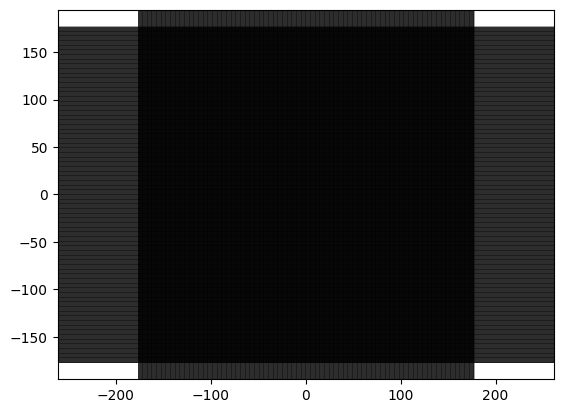

In [14]:
##############################################################################
### Example Initialization ###

# make a 349x349x40000 um mesh, wrapped with 10 PML cells. 
# set the transverse spacing to 0.25 um and the longitudinal spacing to 2 um.

#### Mesh ####
xw = 349 # [um] 
yw= 349 # [um] 
zw = 40000 # [um]

num_PML = 10 

ds = 0.25 # [um]
dz = 50 # [um]

## Adaptive meshing refinement ratio
ref_val = 1e-2

## Create Mesh
_mesh = RectMesh3D(xw, yw, zw,
                   ds, dz, num_PML)

x_grid, y_grid = _mesh.xg[num_PML:-num_PML, num_PML:-num_PML], \
    _mesh.yg[num_PML:-num_PML, num_PML:-num_PML]


### View some properties ###

# shape
print(_mesh.shape)

# shape of transverse grid only
print(_mesh.xy.shape)

# plot the grid lines of the transverse mesh
_mesh.xy.plot_mesh()

## 2. Optics

`Lightbeam` provides a skeleton structure for users to define their own waveguide geometries, as well as some pre-defined classes for certain types of photonic lanterns. We construct a 19cPL object using the `lant19` class, which we will parameterize before propagating light through it.

### 2.1 Initialization

To initialize the 19cPL, we use the lant19 class. The required args are:

<strong>`lant19.__init__()`</strong>

<strong>`rcore`</strong>: radii of the cores.<br>
<strong>`rclad`</strong>: radius of the cladding.<br>
<strong>`ncore`</strong>: refractive index of the cores.<br>
<strong>`njack`</strong>: refractive index of the jacket.<br>
<strong>`core_spacing`</strong>: spacing between cores (inner ring from origin, outer ring from inner ring).<br>
<strong>`z_ex`</strong>: length of the photonic lantern.<br>

(optional)

<strong>`z_offset`</strong>: offset that sets the z-coord for the cylinder's front (default = 0).<br>
<strong>`scale_func`</strong>: function that takes in z_ex and returns a scale value (default = None).<br>
<strong>`final_scale`</strong>: the taper ratio, i.e. the scale of the final cross-section geometry, relative to the initial geoemtry (default = 1).<br>

In [15]:
##############################################################################
### 19cPL Parameterization ###

## Center of the cylinder at z=0
xy = [0,0] 

## Set the final cross-sectional scale
taper_ratio = 10


## Output Radii ##
r_core_1_out = 3.25 # [um]
r_core_2_out = 3.25 # [um]
r_clad_out = 164 # [um]

core_spacing_out = 60 # [um]


## Input Radii ##
r_core_1 = r_core_1_out/taper_ratio # central science core radius (same as others if not HMS) [um]
r_core_2 = r_core_2_out/taper_ratio # outer AO cores radii [um]
r_clad = r_clad_out/taper_ratio # cladding radius [um]

# spacing between cores
core_spacing = core_spacing_out/taper_ratio # [um]

## Refractive Indices ##
n_core = 1.4467895 
n_clad = 1.44 
n_cap = 1.4345


### Create Lantern Object
pl_19 = optics.lant19(r_core_2, 
                      r_clad,
                      n_core, 
                      n_clad, 
                      n_cap,
                      core_spacing, 
                      zw, 
                      z_offset=0,
                      scale_func=None, 
                      final_scale=taper_ratio)

## 3. Propagation

### 3.1 Prop3D Class

Beam propagation is handled by the __`Prop3D`__ class. The technique used to simulate propagation belongs to a class of algorithms that all fall under the umbrella term "finite-differences beam propagation method", or FD-BPM. The particular variant used here follows [1], and works on an adaptive mesh. To initialize a __`Prop3D`__ object, we need to pass in four things:

<strong>`Prop3D.__init__()`</strong>
1. __`wl0`__: the propagation wavelength (remember to keep your units consistent). 
2. __`mesh`__: the __RectMesh3D__ object defining the simulation space sampling.
3. __`optical_system`__: the __OpticalSys__ object defining the waveguide geometry which you want to simulate.
3. __`n0`__: the effective index of propagation for light moving through the waveguide. Physically, this index should be between the highest and lowest indices in the waveguide, which means that setting this to something like a cladding index (recalling we are in the weakly guiding regime) is usually okay. 

### 3.2 Propagation

To actually start the beam propagation, run the function __`Prop3D.prop2end()`__, which takes in a launch field and returns the propagated field at the end of the waveguide. Below are the arguments. <br>

<strong>`Prop3D.prop2end()`</strong> <br>
Arguments
1. __`u`__: 2D complex array defining the launch field. If the shape of this array does not match the shape of the transverse grid of the simulation zone, the field will be resampled on the grid. In terms of normalization, the power of this field should equal $ \sum_{ij} u^*_{ij}u_{ij} $. Alternatively, you can pass in a function of the form f(x,y) with the same normalization. This latter option is more accurate when using adaptive mesh refinement.
(Optional)
2. __`xyslice`__,__`zslice`__: These parameters are arrays of indices which can be used to define a subsection of the field data to save, useful if you want to get cross-sectional images of the electric field as it traverses the waveguide. This feature has not been touched in a while ... so I'm not sure if they still work
3. __`monitor_func`__: pass in a function of the form f(x,y) that returns an electric field; the propagator will compute the overlap of the electric field and this "monitor" field at each propagation step. Can be useful if you want to track the behavior of the electric field as it moves through the waveguide.
4. __`writeto`__: (deprecated) a file name string for where to save field data to.
5. __`ref_val`__: this (float) parameter controls the aggressiveness of the adaptive meshing. Smaller values means more subdivision. At the moment, finding an appropriate value for this parameter requires trial-and-error.
6. __`remesh_every`__: this (int) parameter controls how many z-steps occur before the adaptive mesh is updated.
7. __`dynamic_n0`__: when True, the propagator will average the refractive indices in the waveguide system in order to estimate the effective index. Defaults to `False`.
8. __`fplanewidth`__: here, you can assign a physical extent to the input field __`u`__, which will be accounted form when the field is resampled onto the simulation grid. When set to 0, the propagator assumes that the physical extent of the launch field is the same as that of the transverse grid contained in the __`mesh`__ object (__not__ including PML).

Returns

1. __`u`__: propagated electric field, sampled on the last non-uniform mesh (this __includes__ the PML zone) used by the propagator. Note that the returned field will be in a different normalization scheme than the input field, to account for the adaptive mesh. The field will be normalized such that the field power equals $ \sum_{ij} w_{ij} u^*_{ij}u_{ij} $, where $w_{ij}$ is the area of the grid cell at index [i,j]. Access this weighting factor through __`RectMesh2D.get_weights()`__.
2. __`u0`__: similar to above, but sampled on the __base__ uniform mesh 

A similar propagator, __`prop2end_uniform()`__, is available to handle beam propagation on a fixed, uniform grid.

### 3.3 LP Mode Generation

LP mode transverse field distributions can be generated using the lpfield function in the LPmodes.py script. The lpfield function takes the following arguments: 

<strong>`LPmodes.lpfield`</strong>

<strong>`xg`</strong>: x-axis meshing grid.<br>
<strong>`yg`</strong>: y-axis meshing grid.<br>
<strong>`l`</strong>: LP mode azimuthal index.<br>
<strong>`m`</strong>: LP mode radial index.<br>
<strong>`a`</strong>: radius of core at waveguide input.<br>
<strong>`n_core`</strong>: core refractive index.<br>
<strong>`n_clad`</strong>: cladding refractive index.<br>

(optional)

<strong>`which`</strong>: LP mode azimuthal component is either a cosine or sine, choose either 'cos' or 'sin' (default='cos').<br>

Note that the LP mode field is normalized after generation, and that the grid meshing is repeated in the coded example.

input field: 


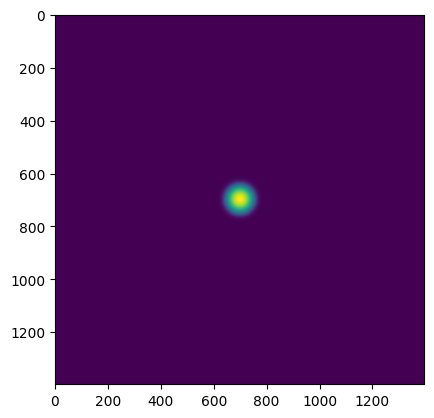

In [16]:
#%%###########################################################################
### Set LP Mode Injection Parameters

wl = 1.5 # wavelength [um]

## LP mode indices (l, m)
mode = [0, 1] # LP01 mode

#### Mesh ####
xw = 349 # [um] 
yw= 349 # [um] 
z_len = 40000 # [um]

num_PML = 10 # grid units -> 8

ds = 0.25 # [um]
dz = 2 # [um]

## Adaptive meshing refinement ratio
ref_val = 1e-2

## Create Mesh
_mesh = RectMesh3D(xw, yw, z_len,
                   ds, dz, num_PML)

x_grid, y_grid = _mesh.xg[num_PML:-num_PML, num_PML:-num_PML], \
    _mesh.yg[num_PML:-num_PML, num_PML:-num_PML]


## Output Radii ##
r_core_1_out = 3.25 # [um]
r_core_2_out = 3.25 # [um]
r_clad_out = 164 # [um]

## Set the final cross-sectional scale
taper_ratio = 10

## Input Radii ##
r_core_1 = r_core_1_out/taper_ratio # central science core radius (same as others if not HMS) [um]
r_core_2 = r_core_2_out/taper_ratio # outer AO cores radii [um]
r_clad = r_clad_out/taper_ratio # cladding radius [um]

## Refractive Indices ##
n_core = 1.4467895 
n_clad = 1.44 
n_cap = 1.4345

## Generate LP mode transverse field
u0 = normalize(LPmodes.lpfield(x_grid, y_grid, 
                                mode[0],
                                mode[1],
                                r_clad,
                                wl,
                                n_core,
                                n_clad))


print("input field: ")
plt.imshow(np.abs(u0))
plt.show()

### 3.4 Propagation Example

We now propagate the LP01 mode through the 19cPL object using the function __`Prop3D.prop2end()`__.


In [ ]:
#%%###########################################################################
### Propagation ####

## Propagate 
prop = Prop3D(wl,       # wavelength
            _mesh,      # mesh    
            pl_19,      # optical system
            n_clad)     # cladding refractive index

u_out_weighted, u_out_2, u_out_weights = prop.prop2end(u0,
                                                        ref_val=ref_val,
                                                        remesh_every=50)


## Calculate Unweighted Output Field
u_out = unweight_field(u_out_weighted, u_out_weights)

print("Output power (unweighted):", np.sum(np.abs(u_out_weighted)**2 \
                                            * u_out_weights))

Input power (uniform): 0.0625
input power:  1.0
input power preserved:  1.0
propagating field...
initial shape:  (1417, 1417)


KeyboardInterrupt: 

### 3.5 Code Example: Propagate 17 LP Modes Through 19cPL

Here we provide an example code of for using `Lightbeam` to propagate 17 LP modes through a 19cPL.

In [ ]:
#%%###########################################################################
'''
Propagates 17 LP modes through a 19-core a photonic lantern using lightbeam

'''

#%%###########################################################################
### Limit Number of Cores

import os

# limit core usage
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"
os.environ["VECLIB_MAXIMUM_THREADS"] = "2"
print("Thread limits set.")

#%%###########################################################################
### Import Libraries and Modules

import numpy as np
import h5py
import matplotlib.pyplot as plt

import lightbeam
import lightbeam.optics as optics
from lightbeam import LPmodes
from lightbeam.mesh import RectMesh3D
from lightbeam.misc import normalize, unweight_field
from lightbeam.prop import Prop3D


#%%###########################################################################
### Code example: 19 port lantern ###

## Set Parameters and Variables

wl = 1.5 # wavelength [um]

#### Mesh ####
xw = 349 # [um] 
yw= 349 # [um] 
z_len = 40000 # [um]

num_PML = 10 # perfectly matched layers

ds = 0.25 # [um]
dz = 2 # [um]

## Adaptive meshing refinement ratio
ref_val = 1e-2

## Create Mesh
_mesh = RectMesh3D(xw, yw, z_len,
                   ds, dz, num_PML)

x_grid, y_grid = _mesh.xg[num_PML:-num_PML, num_PML:-num_PML], \
    _mesh.yg[num_PML:-num_PML, num_PML:-num_PML]

## Set the final cross-sectional scale
taper_ratio = 10

## Output Radii ##
r_core_1_out = 3.25 # [um]
r_core_2_out = 3.25 # [um]
r_clad_out = 164 # [um]

core_spacing_out = 60 # [um]

## Input Radii ##
r_core_1 = r_core_1_out/taper_ratio # central science core radius [um]
r_core_2 = r_core_2_out/taper_ratio # outer AO cores radii [um]
r_clad = r_clad_out/taper_ratio # cladding radius [um]

# spacing between cores
core_spacing = core_spacing_out/taper_ratio # [um]

## Refractive Indices ##
n_core = 1.4467895 
n_clad = 1.44 
n_cap = 1.4345


#%% Create Lantern Object

pl_19 = optics.lant19(r_core_2, 
                      r_clad,
                      n_core, 
                      n_clad, 
                      n_cap,
                      core_spacing, 
                      z_len, 
                      z_offset=0,
                      scale_func=None, 
                      final_scale=taper_ratio)



#%%###########################################################################
### Initialise

## Set Modes Manually
modes = [[0, 1],
          [0, 2],
          [0, 3],
          [1, 1],
          [1, 1],
          [1, 2],
          [1, 2],
          [2, 1],
          [2, 1],
          [2, 2],
          [2, 2],
          [3, 1],
          [3, 1],
          [3, 2],
          [3, 2],
          [4, 1],
          [4, 1],
          [5, 1],
          [5, 1]]


n_modes = len(modes)

modes_flip = ['cos', 'sin']

## Initialise Arrays to Store Data
u0 = []
U_out_weighted_array = []
U_out_weights_array = []
U_out_array = []

#%% File Names

f_path = 'Results/'
f_suffix = f'ds={ds}_dz={dz}_rv={ref_val}_xyw={xw}_zlen={z_len}_tr={taper_ratio}'


#%%###########################################################################
### Loop Through Modes

## Loop Through Propagation Modes
for i in range(n_modes):
    if modes[i][0] == 0:
        u0 = normalize(LPmodes.lpfield(x_grid, y_grid, 
                                        modes[i][0],
                                        modes[i][1],
                                        r_clad,
                                        wl,
                                        n_core,
                                        n_clad))
        
        ab = ''
        
    else:
        if i % 2 == 1:
            u0 = normalize(LPmodes.lpfield_fixed(x_grid, y_grid, 
                                            modes[i][0],
                                            modes[i][1],
                                            r_clad,
                                            wl,
                                            n_core,
                                            n_clad,
                                            which=modes_flip[0]))
            
            ab = 'a'

        else:
            u0 = normalize(LPmodes.lpfield_fixed(x_grid, y_grid, 
                                            modes[i][0],
                                            modes[i][1],
                                            r_clad,
                                            wl,
                                            n_core,
                                            n_clad,
                                            which=modes_flip[1]))
            
            ab = 'b'


    # print('u0 shape =', np.shape(u0))
    # print("Input power (uniform):", np.sum(np.abs(u0)**2) * ds * ds)
    
    #### propagation ####
    print("Propagating core:", i)
    prop = Prop3D(wl,       # wavelength
                _mesh,      # mesh    
                pl_19,      # optical system
                n_clad)     # cladding refractive index

    
    
    ## prop2end
    u_out_weighted, u_out_2, u_out_weights = prop.prop2end(u0,
                                                          ref_val=ref_val,
                                                          remesh_every=50)
    
    # print('u_out_shape =', np.shape(u_out_weighted))
    
    ## Calculate Unweighted Output Field
    u_out = unweight_field(u_out_weighted, u_out_weights)

    # print("Output power (uniform):", np.sum(np.abs(u_out)**2) * ds * ds)
    print("Output power (unweighted):", np.sum(np.abs(u_out_weighted)**2 \
                                             * u_out_weights))


    ## Append output to list
    U_out_weighted_array.append(u_out_weighted)
    U_out_weights_array.append(u_out_weights)
    U_out_array.append(u_out)


    ## Plot Output Fields
    [fig2, axs2] = plt.subplots(1, 2, 
                        sharex=True, 
                        sharey=True, 
                        tight_layout=True, 
                        figsize=(8, 4))
    axs2[0].set_title(f'Output Intensity: LP{modes[i][0], modes[i][1]}{ab}', 
                      fontsize=14)
    axs2[1].set_title(f'Output Phase: LP{modes[i][0], modes[i][1]}{ab}', 
                      fontsize=14)
    im2 = axs2[0].imshow(np.abs(u_out)**2,
            cmap='viridis',
            origin='lower',
            label='b)')
    im2 = axs2[1].imshow(np.angle(u_out),
            cmap='twilight',
            origin='lower',
            label='b)')
    plt.tight_layout()
    plt.show()

    plt.close(fig2)


#%% Covert to Arrays
U_out_weighted_array = np.array(U_out_weighted_array)
U_out_array = np.array(U_out_array)
U_out_weights_array = np.array(U_out_weights_array)


#%%###########################################################################
### Save Outputs

print("Saving...")


U_out_weighted_data = h5py.File(f_path+'U_out_weighted_array_'+f_suffix+'.h5', 'w')
U_out_weighted_data.create_dataset('U_out_weighted', data=U_out_weighted_array)
U_out_weighted_data.close()

U_out_data = h5py.File(f_path+'U_out_array_'+f_suffix+'.h5', 'w')
U_out_data.create_dataset('U_out', data=U_out_array)
U_out_data.close()

U_out_weights_data = h5py.File(f_path+'U_out_weights_array_'+f_suffix+'.h5', 'w')
U_out_weights_data.create_dataset('U_out_weights', data=U_out_weights_array)
U_out_weights_data.close()



Thread limits set.
MODES SUPPORTED:  [[0, 1], [0, 2], [0, 3], [1, 1], [1, 1], [1, 2], [1, 2], [2, 1], [2, 1], [2, 2], [2, 2], [3, 1], [3, 1], [3, 2], [3, 2], [4, 1], [4, 1], [5, 1], [5, 1]]
Input power (uniform): 0.0625
Propagating core: 0
input power:  1.0
input power preserved:  1.0


KeyboardInterrupt: 

For more examples on running `lightbeam`, check out `Lightbeam.ipynb` (the Part I tutorial), `run_bpm_example.py` and `config_example.py` in the __tutorial__ folder.

## 6. References 

[1] Barnaby RM. Norris, Jin Wei, Chris H. Betters, Alison Wong, Sergio G. Leon-Saval, "An all-photonic focal-plane wavefront sensor," Nature Commun. 11, 5335 (2020) <br>

[2] Jun Shibayama, Kenji Matsubara, Minoru Sekiguchi, Junji Yamauchi, and Hisamatsu Nakano, "Efficient Nonuniform Schemes for Paraxial and Wide-Angle Finite-Difference Beam Propagation Methods," J. Lightwave Technol. 17, 677- (1999) <br>

[3] Ginés Lifante Pedrola, "Beam Propagation Method for Design of Optical Waveguide Devices," Wiley (2015) <br>

[4] Srikar Srinath, Lisa A. Poyneer, Alexander R. Rudy, and S. Mark Ammons, "Computationally efficient autoregressive method for generating phase screens with frozen flow and turbulence in optical simulations," Opt. Express 23, 33335-33349 (2015)
